# Stochastic Interpolant — Minimal Evaluation

**What this notebook does, step by step:**

1. Load a trained drift model `b(x, t, x0)` from a checkpoint
2. Pick a vorticity field `x0` from the test set as the initial condition
3. Integrate the learned SDE forward in time (Euler-Maruyama) to produce a forecast
4. Repeat step 3 several times to get an **ensemble** of possible futures
5. Do this for multiple forecast horizons (lag-1τ, lag-2τ, ...) by chaining steps
6. Compare visually against the ground truth

---
**Recall the key idea of Stochastic Interpolants for forecasting:**

We have pairs `(x0, x1)` from a time series with lag τ.  
The interpolant is: `I_s = α_s * x0 + β_s * x1 + σ_s * W_s`  
At s=0: `I_0 = x0` (point mass at current state)  
At s=1: `I_1 = x1` (sample from conditional distribution at t+τ)  

We train a neural network `b(x, s, x0)` to approximate the drift of the SDE  
whose marginals match those of the interpolant.  
At test time, we solve this SDE starting from `X_0 = x0`  
to get a sample `X_1 ~ p(x_{t+τ} | x_t)`.

For **multi-step forecasting**, we just chain: use `X_1` as the new `x0` and solve again.

## Step 0 — Imports

In [1]:
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Point this to the folder containing utils.py and interpolant.py
sys.path.insert(0, '.')

from utils import DriftModel, get_forecasting_dataloader, maybe_create_dir
from interpolant import Interpolant

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Step 1 — Load the checkpoint and reconstruct the model

We inspect the saved weights to figure out the architecture automatically,
so we don't need to remember exactly what hyperparameters were used during training.

In [2]:
CKPT_PATH = '../../checkpoints/latest_gooddata.pt'

ckpt = torch.load(CKPT_PATH, map_location='cpu')
sd   = ckpt['model_state_dict']   # the raw weight dictionary
print(f'Checkpoint was saved at training step: {ckpt["step"]}')
print(f'Number of weight tensors in checkpoint: {len(sd)}')

Checkpoint was saved at training step: 100000
Number of weight tensors in checkpoint: 277


In [3]:
# ── Infer architecture from weight shapes ─────────────────────────────────────
#
# The UNet has a predictable structure. We read the shapes of a few key
# weights to reconstruct the config without guessing.

import itertools

# unet_channels: width of the first conv layer
base_ch = sd['_arch.init_conv.weight'].shape[0]

# Number of down-sampling levels
n_levels = max(int(k.split('.')[2]) for k in sd if k.startswith('_arch.downs.')) + 1

# Attention heads: inferred from mid-block attention weight shape
qkv_out = sd['_arch.mid_attn.fn.fn.to_qkv.weight'].shape[0]  # = 3 * heads * dim_head
attn_heads, attn_dim_head = 4, 32
for h in [1, 2, 4, 8]:
    if qkv_out % (3 * h) == 0:
        attn_heads    = h
        attn_dim_head = qkv_out // (3 * h)
        break

# Sinusoidal time embedding dim
learned_sin_dim = sd['_arch.time_mlp.1.weight'].shape[1] - 1

print(f'Detected:  base_ch={base_ch}, n_levels={n_levels}')
print(f'           attn_heads={attn_heads}, attn_dim_head={attn_dim_head}')
print(f'           learned_sin_dim={learned_sin_dim}')

# Find the dim_mults tuple by trying all non-decreasing combos from {1,2,4,8}
# (only ~35 options for 4 levels — this takes < 5 seconds)
candidates = [
    m for m in itertools.product([1, 2, 4, 8], repeat=n_levels)
    if m[0] == 1 and all(m[i] <= m[i+1] for i in range(len(m)-1))
]
print(f'\nSearching over {len(candidates)} possible dim_mults ...')

# Minimal config object — only the fields DriftModel needs
class Config:
    dataset                    = 'nse'
    C                          = 1
    H                          = 128
    W                          = 128
    num_classes                = 1
    unet_use_classes           = False
    unet_resnet_block_groups   = 8
    unet_learned_sinusoidal_cond    = True
    unet_random_fourier_features    = False
    # will be filled in below:
    unet_channels              = base_ch
    unet_dim_mults             = (1, 2, 2, 2)   # placeholder
    unet_attn_heads            = attn_heads
    unet_attn_dim_head         = attn_dim_head
    unet_learned_sinusoidal_dim = learned_sin_dim

c = Config()

winner = None
for mults in candidates:
    c.unet_dim_mults = mults
    try:
        m = DriftModel(c)
        m.load_state_dict(sd, strict=True)
        winner = mults
        break
    except RuntimeError:
        pass

if winner is None:
    raise RuntimeError('Could not find matching dim_mults. Check the checkpoint.')

c.unet_dim_mults = winner
print(f'\n✓ Found dim_mults = {winner}')

Detected:  base_ch=128, n_levels=4
           attn_heads=1, attn_dim_head=256
           learned_sin_dim=32

Searching over 20 possible dim_mults ...
NOT USING CLASSES IN UNET
Num params in main arch for drift is 12,212,625
NOT USING CLASSES IN UNET
Num params in main arch for drift is 17,198,481
NOT USING CLASSES IN UNET
Num params in main arch for drift is 34,444,689
NOT USING CLASSES IN UNET
Num params in main arch for drift is 98,035,089
NOT USING CLASSES IN UNET
Num params in main arch for drift is 23,478,929
NOT USING CLASSES IN UNET
Num params in main arch for drift is 41,970,321
NOT USING CLASSES IN UNET
Num params in main arch for drift is 108,051,089
NOT USING CLASSES IN UNET
Num params in main arch for drift is 64,296,081
NOT USING CLASSES IN UNET
Num params in main arch for drift is 135,357,585
NOT USING CLASSES IN UNET
Num params in main arch for drift is 219,068,561
NOT USING CLASSES IN UNET
Num params in main arch for drift is 29,988,753

✓ Found dim_mults = (1, 2, 2, 2)

In [4]:
# Build the final model and load weights
model = DriftModel(c).to(device)
model.load_state_dict(sd, strict=True)
model.eval()   # IMPORTANT: disables dropout / batchnorm training behaviour

n_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded. Parameters: {n_params/1e6:.2f} M')

NOT USING CLASSES IN UNET
Num params in main arch for drift is 29,988,753
Model loaded. Parameters: 29.99 M


## Step 2 — Load a few test samples

Each sample is a pair `(xlo, xhi)` = `(ω_t, ω_{t+τ})`.  
We will use `xlo` as the initial condition and compare our forecast to `xhi`.

In [5]:
# A few extra config fields needed for the dataloader
c.data_fname        = '../../../fm_tutorial/dataset_gen/dataset/test_128.pt'
c.lo_size           = 128
c.hi_size           = 128
c.time_lag          = 2
c.subsampling_ratio = 1.0
c.num_workers       = 0
c.batch_size        = 8
c.center_data       = False
c.home              = './eval_out'
c.sigma_coef        = 1.0
c.beta_fn           = 't^2'    # must match what you trained with: 't' or 't^2'
c.noise_strength    = 1.0
c.delta_t           = 0.5
c.use_wandb         = False
c.debug             = False

maybe_create_dir('./eval_out')

# get_forecasting_dataloader also returns the pixel normalisation constant
# that was applied to the data before training.
# To get back physical vorticity values, multiply outputs by old_pixel_norm.
loader, old_pixel_norm, new_pixel_norm = get_forecasting_dataloader(c)
c.old_pixel_norm = old_pixel_norm
c.new_pixel_norm = new_pixel_norm

print(f'Normalisation constant (old_pixel_norm): {old_pixel_norm:.4f}')
print(f'  → model inputs are vorticity / {old_pixel_norm:.4f}')
print(f'  → to get back physical units, multiply by {old_pixel_norm:.4f}')

# Grab one batch and keep it fixed for all experiments below
xlo_batch, xhi_batch = next(iter(loader))   # xlo = ω_t,  xhi = ω_{t+τ}
xlo_batch = xlo_batch.to(device)            # shape: [B, 1, H, W]  (normalised)
xhi_batch = xhi_batch.to(device)
print(f'\nBatch shape: {xlo_batch.shape}  (B, C, H, W)')
print(f'Vorticity range in batch: [{(xhi_batch * old_pixel_norm).min():.2f}, '
                                 f'{(xhi_batch * old_pixel_norm).max():.2f}]')

Normalisation constant (old_pixel_norm): 0.2612
  → model inputs are vorticity / 0.2612
  → to get back physical units, multiply by 0.2612

Batch shape: torch.Size([8, 1, 128, 128])  (B, C, H, W)
Vorticity range in batch: [-1.09, 1.21]


## Step 3 — The SDE sampler (Euler-Maruyama)

This is the core function. It integrates the SDE:

```
dX_s = b(X_s, s, x0) ds  +  σ_s dW_s
X_0  = x0
```

from `s=0` to `s=1` using the Euler-Maruyama scheme:

```
X_{s+Δs} = X_s  +  b(X_s, s, x0) * Δs  +  σ_s * √Δs * ε,   ε ~ N(0,I)
```

The variable `s` here is the **interpolant time**, not physical time.  
Each full integration from s=0 to s=1 produces one forecast at physical lag τ.

At the very last step we return the **mean** (without the noise term) for a cleaner image.

In [6]:
@torch.no_grad()   # no gradients needed at test time → saves memory
def forecast_one_step(model, interpolant, x0, n_steps=200):
    """
    Given x0 (shape [B, C, H, W], normalised), produce one forecast at lag τ.

    Integrates the learned SDE from s=0 to s=1 using Euler-Maruyama.

    Returns:
        sample   : [B, C, H, W]  — final sample (last step mean, no noise)
        trajectory: list of [B, C, H, W] tensors saved every save_every steps
                    (useful to visualise how the SDE evolves from x0 → x1)
    """
    # s runs from 0 to ~1 (we stop just before 1 to avoid boundary issues)
    s_values = torch.linspace(0.0, 0.999, n_steps).to(x0)
    ds       = s_values[1] - s_values[0]       # step size Δs

    # One scalar s per sample in the batch
    ones = torch.ones(x0.shape[0], device=x0.device, dtype=x0.dtype)

    x = x0.clone()   # X_0 = x0  (start exactly at the initial condition)

    trajectory = [x0.cpu()]   # save initial condition
    save_every = max(1, n_steps // 5)   # save ~5 snapshots along the SDE path

    for i, s_scalar in enumerate(s_values):

        s_vec = s_scalar * ones   # shape [B] — same s for every sample in batch

        # ── Evaluate drift b(X_s, s, x0) ────────────────────────────────────
        # The model takes:
        #   x      = current state X_s
        #   s_vec  = current interpolant time
        #   label  = class label (None for NSE)
        #   cond   = conditioning info = x0 (the initial condition we start from)
        drift = model(x, s_vec, None, cond=x0)   # shape [B, C, H, W]

        # ── Evaluate σ_s (diffusion coefficient) ────────────────────────────
        # σ_s comes from the interpolant: for α=1-s, σ=1-s we have σ_s = 1-s
        # The interpolant object computes this correctly for any choice of coefficients
        sigma_s = interpolant.sigma(s_vec)        # shape [B] or scalar

        # ── Euler-Maruyama step ──────────────────────────────────────────────
        noise     = torch.randn_like(x)           # ε ~ N(0, I)
        x_mean    = x + drift * ds                # deterministic part
        x         = x_mean + sigma_s * noise * ds.sqrt()   # add stochasticity

        if i % save_every == 0:
            trajectory.append(x.cpu())

    # Return the mean at the last step (no noise → less granular but cleaner)
    trajectory.append(x_mean.cpu())
    return x_mean, trajectory


# Quick sanity check: shape should match input
x0_test = xlo_batch[0:1]   # single sample, shape [1, 1, 128, 128]
I = Interpolant(c)
out, traj = forecast_one_step(model, I, x0_test, n_steps=50)  # fast test
print(f'Input shape:  {x0_test.shape}')
print(f'Output shape: {out.shape}   ✓' if out.shape == x0_test.shape else f'Shape mismatch!')
print(f'SDE trajectory has {len(traj)} saved snapshots')

Input shape:  torch.Size([1, 1, 128, 128])
Output shape: torch.Size([1, 1, 128, 128])   ✓
SDE trajectory has 7 saved snapshots


## Step 4 — Visualise how the SDE walks from x0 to x1

This is a diagnostic to build intuition: we watch the interpolant time `s` go from 0 to 1.
- At s=0 the field is exactly x0 (the initial condition)
- As s increases the SDE explores the distribution
- At s=1 we get a sample from p(ω_{t+τ} | ω_t)

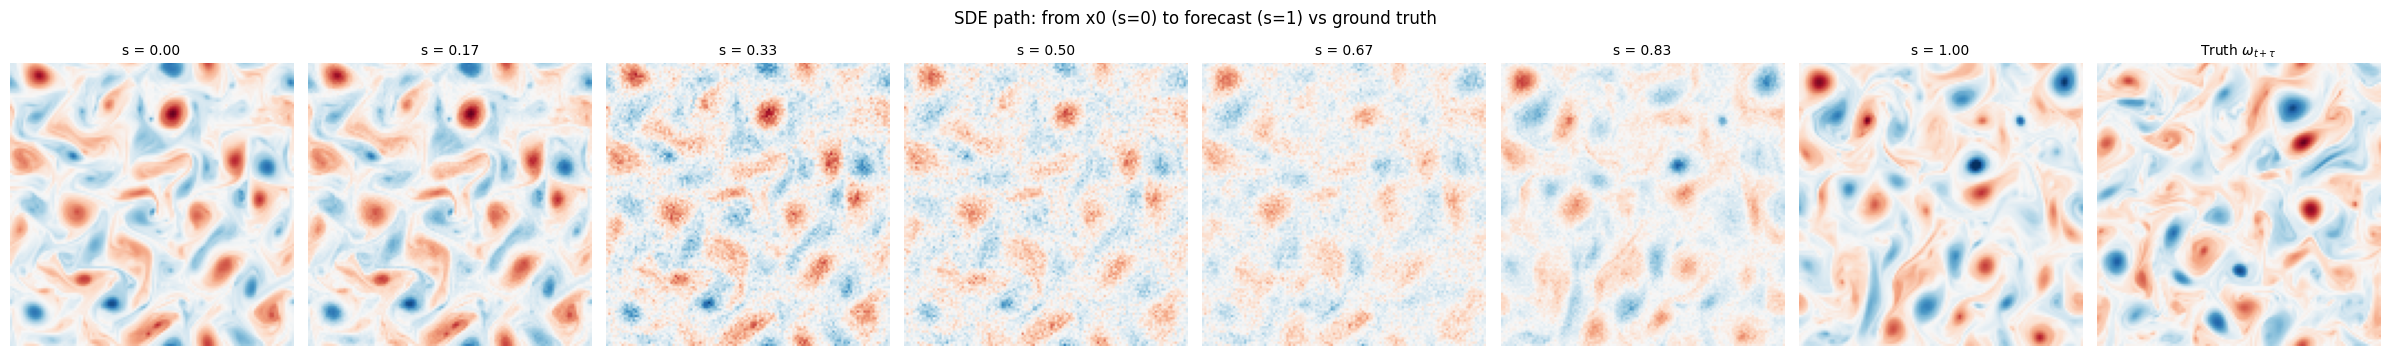

Note: the forecast is a SAMPLE from p(ω_{t+τ}|ω_t), not the mean.
It will look different from the truth but should have the same statistics.


In [7]:
IDX = 0   # which sample in the batch to visualise

x0 = xlo_batch[IDX:IDX+1]   # initial condition  ω_t
x1_true = xhi_batch[IDX]    # ground truth        ω_{t+τ}

# Run the SDE with 200 steps (good quality)
forecast, trajectory = forecast_one_step(model, I, x0, n_steps=200)

# Convert to physical vorticity (multiply by normalisation constant)
def to_phys(tensor):
    """Remove channel dim and rescale to physical vorticity units."""
    return tensor[0, 0].cpu().numpy() * old_pixel_norm

# Build a symmetric colormap centred on 0 (vorticity can be positive or negative)
all_vals = np.abs(to_phys(x1_true.unsqueeze(0))).max()
vmax = np.max(all_vals)
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)

# Plot the SDE snapshots
n_snaps = len(trajectory)
fig, axes = plt.subplots(1, n_snaps + 1, figsize=(3 * (n_snaps + 1), 3.5))

s_labels = np.linspace(0, 1, n_snaps)
for i, (ax, snap) in enumerate(zip(axes[:-1], trajectory)):
    ax.imshow(to_phys(snap), cmap='RdBu_r', norm=norm)
    ax.set_title(f's = {s_labels[i]:.2f}', fontsize=10)
    ax.axis('off')

# Last panel: ground truth at lag τ
axes[-1].imshow(to_phys(x1_true.unsqueeze(0)), cmap='RdBu_r', norm=norm)
axes[-1].set_title(r'Truth $\omega_{t+\tau}$', fontsize=10)
axes[-1].axis('off')

plt.suptitle('SDE path: from x0 (s=0) to forecast (s=1) vs ground truth',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('./eval_out/sde_path.png', bbox_inches='tight', dpi=150)
plt.show()
print('Note: the forecast is a SAMPLE from p(ω_{t+τ}|ω_t), not the mean.')
print('It will look different from the truth but should have the same statistics.')

## Step 5 — Ensemble: multiple possible futures from the same initial condition

Because the SDE has noise, every run from the same x0 gives a **different** forecast.  
This is the whole point of probabilistic forecasting: the model captures uncertainty.

We run the SDE `N_ENSEMBLE` times from the same x0 to get an ensemble.

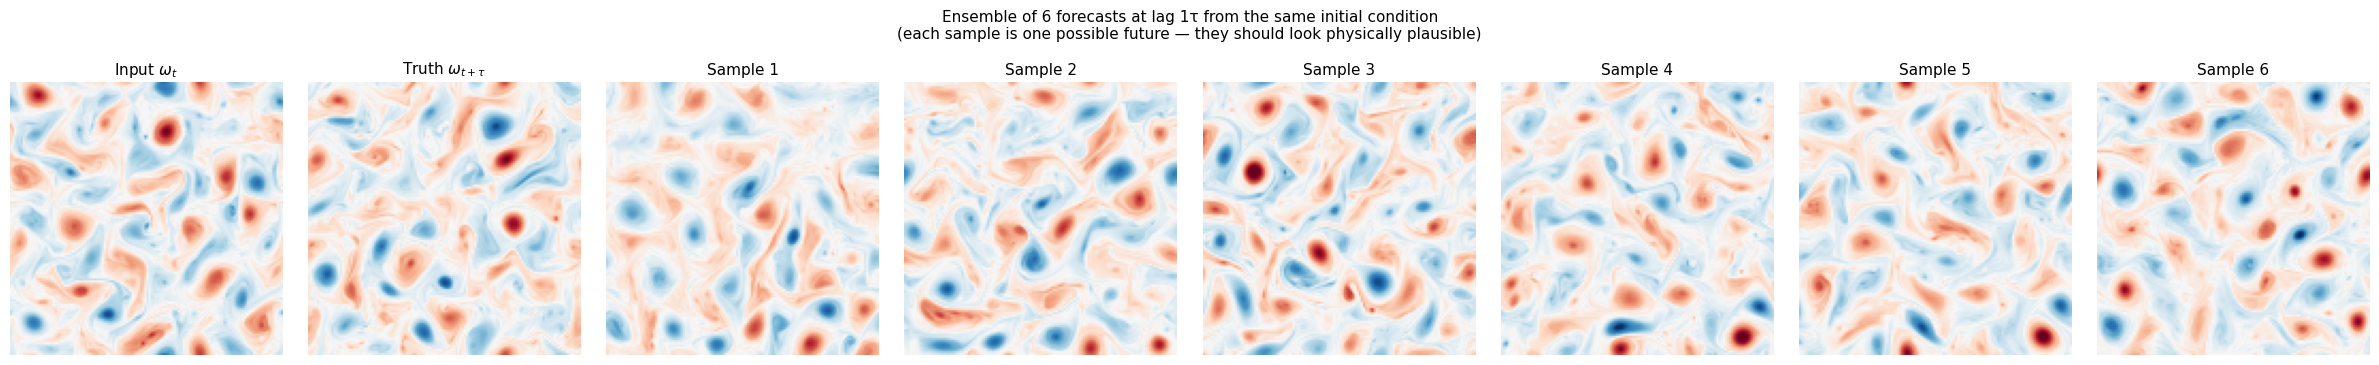

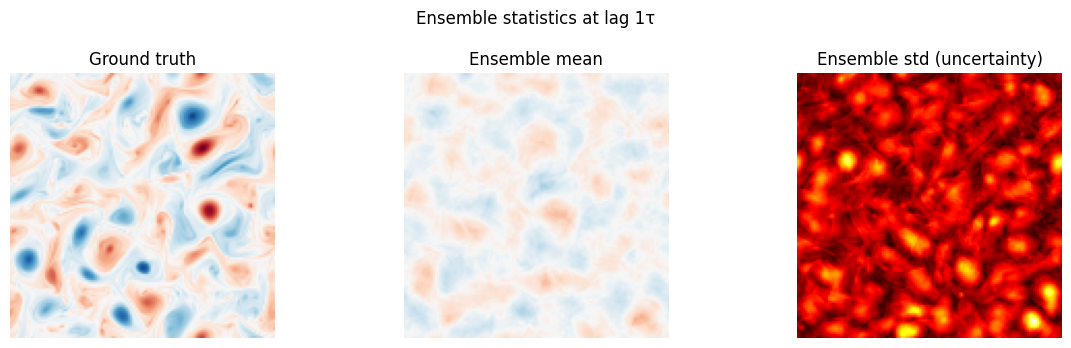

Ensemble mean error (vs truth): 0.2099
Ensemble mean std (uncertainty): 0.1997


In [8]:
N_ENSEMBLE = 6
IDX        = 0
N_STEPS    = 200

x0      = xlo_batch[IDX:IDX+1]   # shape [1, 1, H, W]
x1_true = xhi_batch[IDX]         # shape [1, H, W] — ground truth

# Run the SDE N_ENSEMBLE times independently from the same x0
# Each call draws fresh noise → different realisation of ω_{t+τ}
samples = []
for e in range(N_ENSEMBLE):
    sample, _ = forecast_one_step(model, I, x0, n_steps=N_STEPS)
    samples.append(to_phys(sample))

x0_phys    = to_phys(x0)
truth_phys = to_phys(x1_true.unsqueeze(0))

vmax = np.abs(truth_phys).max()
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)

fig, axes = plt.subplots(1, N_ENSEMBLE + 2, figsize=(3 * (N_ENSEMBLE + 2), 3.5))

axes[0].imshow(x0_phys,    cmap='RdBu_r', norm=norm)
axes[0].set_title(r'Input $\omega_t$', fontsize=11)
axes[0].axis('off')

axes[1].imshow(truth_phys, cmap='RdBu_r', norm=norm)
axes[1].set_title(r'Truth $\omega_{t+\tau}$', fontsize=11)
axes[1].axis('off')

for e, sample in enumerate(samples):
    axes[e + 2].imshow(sample, cmap='RdBu_r', norm=norm)
    axes[e + 2].set_title(f'Sample {e+1}', fontsize=11)
    axes[e + 2].axis('off')

plt.suptitle(
    f'Ensemble of {N_ENSEMBLE} forecasts at lag 1τ from the same initial condition\n'
    '(each sample is one possible future — they should look physically plausible)',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig('./eval_out/ensemble_lag1.png', bbox_inches='tight', dpi=150)
plt.show()

# Ensemble mean and std — summarise the uncertainty
ensemble_stack = np.stack(samples)   # shape [N_ENSEMBLE, H, W]
ens_mean = ensemble_stack.mean(axis=0)
ens_std  = ensemble_stack.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(truth_phys, cmap='RdBu_r', norm=norm);   axes[0].set_title('Ground truth')
axes[1].imshow(ens_mean,   cmap='RdBu_r', norm=norm);   axes[1].set_title('Ensemble mean')
axes[2].imshow(ens_std,    cmap='hot',    vmin=0);       axes[2].set_title('Ensemble std (uncertainty)')
for ax in axes: ax.axis('off')
plt.suptitle('Ensemble statistics at lag 1τ', fontsize=12)
plt.tight_layout()
plt.savefig('./eval_out/ensemble_stats_lag1.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Ensemble mean error (vs truth): {np.abs(ens_mean - truth_phys).mean():.4f}')
print(f'Ensemble mean std (uncertainty): {ens_std.mean():.4f}')

## Step 6 — Multi-step autoregressive forecast

To forecast further into the future (lag 2τ, 3τ, ...) we just chain the steps:
- Forecast at lag 1τ from ω_t      → get ω̂_{t+τ}
- Forecast at lag 2τ from ω̂_{t+τ}  → get ω̂_{t+2τ}
- ... and so on

No retraining is needed. The **same** model is applied repeatedly.

For each lag we also generate multiple ensemble members to show the growing uncertainty.

In [9]:
MAX_LAG    = 5    # forecast up to lag 5τ
N_MEMBERS  = 4   # ensemble members to show per lag
N_STEPS    = 200  # EM steps per SDE integration
IDX        = 0

x0_init = xlo_batch[IDX:IDX+1]   # starting point: ω_t

# Each ensemble member evolves independently.
# member_states[e] = current state of ensemble member e
member_states = [x0_init.clone() for _ in range(N_MEMBERS)]

# We'll also try to collect the matching ground-truth frames
# by iterating through the test loader. (May not align exactly if
# the dataset doesn't give consecutive frames — that's fine.)
gt_frames = [xlo_batch[IDX:IDX+1]]   # lag 0: the input itself
gt_iter   = iter(loader)
for _ in range(MAX_LAG):
    try:
        xlo_next, xhi_next = next(gt_iter)
        gt_frames.append(xhi_next[IDX:IDX+1].to(device))
    except StopIteration:
        break

# ── Autoregressive rollout ─────────────────────────────────────────────────────
# all_forecasts[lag][member] = vorticity field (numpy, physical units)
all_forecasts = []   # outer list = lags 1..MAX_LAG

for lag in range(1, MAX_LAG + 1):
    lag_samples = []
    for e in range(N_MEMBERS):
        # Integrate SDE one step forward from the current state of member e
        next_state, _ = forecast_one_step(model, I, member_states[e], n_steps=N_STEPS)
        lag_samples.append(to_phys(next_state))
        member_states[e] = next_state   # advance this member's state
    all_forecasts.append(lag_samples)
    print(f'Lag {lag}τ done.')

print('\nAll lags computed.')

Lag 1τ done.
Lag 2τ done.
Lag 3τ done.
Lag 4τ done.
Lag 5τ done.

All lags computed.


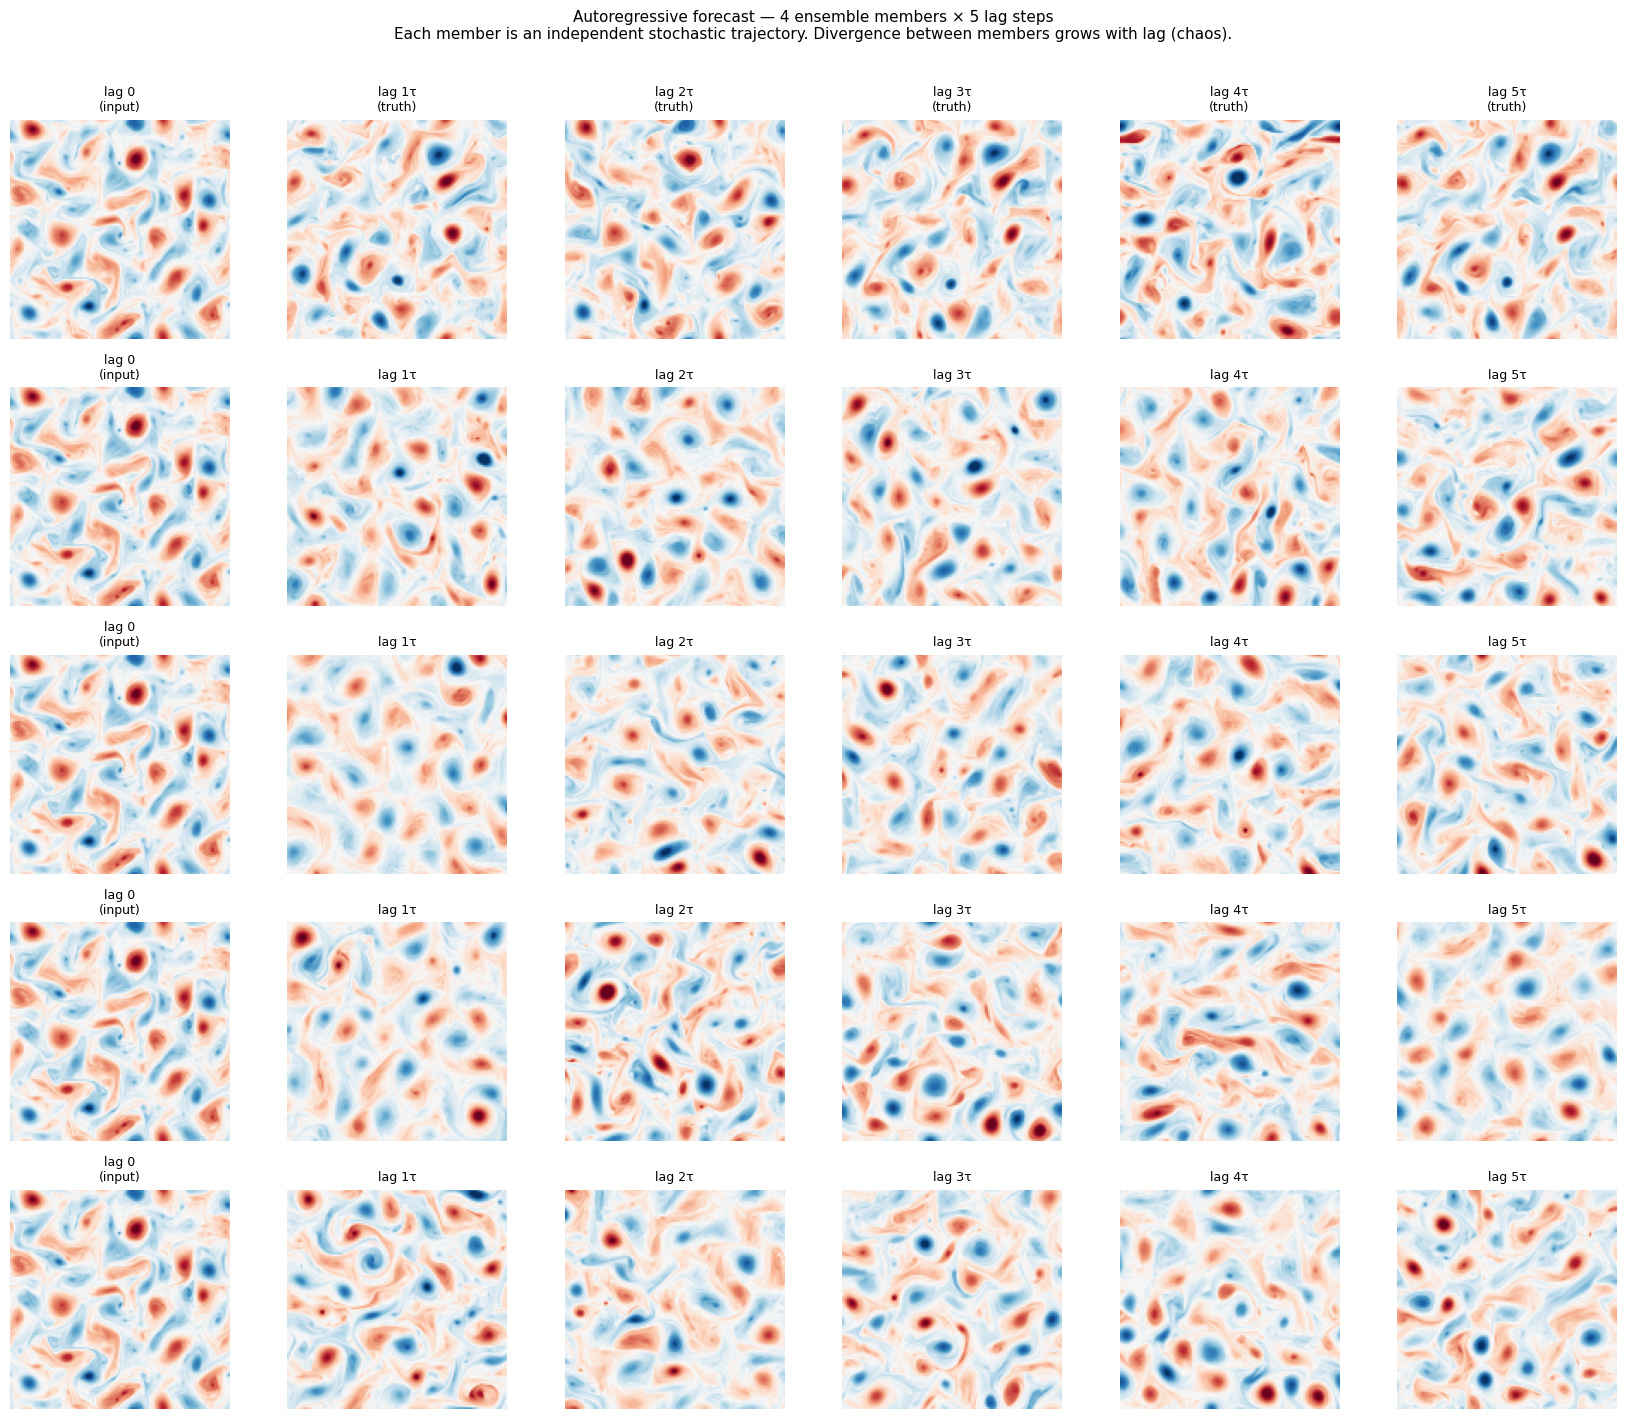

In [10]:
# ── Plot: rows = ensemble members, columns = lag times ────────────────────────

vmax = 1.0
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)

n_cols = MAX_LAG + 1    # lag 0 (input) + lags 1..MAX_LAG
n_rows = N_MEMBERS + 1  # N members + 1 ground-truth row at the top

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(2.8 * n_cols, 2.8 * n_rows))

# ── Top row: ground truth ─────────────────────────────────────────────────────
axes[0, 0].imshow(to_phys(x0_init), cmap='RdBu_r', norm=norm)
axes[0, 0].set_title('lag 0\n(input)', fontsize=9)
axes[0, 0].set_ylabel('Ground truth', fontsize=9, rotation=90, labelpad=4)

for lag in range(1, MAX_LAG + 1):
    ax = axes[0, lag]
    if lag < len(gt_frames):
        ax.imshow(to_phys(gt_frames[lag]), cmap='RdBu_r', norm=norm)
        ax.set_title(f'lag {lag}τ\n(truth)', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'lag {lag}τ\n(truth unavail.)', fontsize=9)

# ── Lower rows: ensemble member forecasts ─────────────────────────────────────
for e in range(N_MEMBERS):
    axes[e + 1, 0].imshow(to_phys(x0_init), cmap='RdBu_r', norm=norm)
    axes[e + 1, 0].set_ylabel(f'Member {e+1}', fontsize=9, rotation=90, labelpad=4)
    axes[e + 1, 0].set_title('lag 0\n(input)', fontsize=9)

    for lag in range(1, MAX_LAG + 1):
        axes[e + 1, lag].imshow(all_forecasts[lag - 1][e], cmap='RdBu_r', norm=norm)
        axes[e + 1, lag].set_title(f'lag {lag}τ', fontsize=9)

for ax in axes.ravel():
    ax.axis('off')

plt.suptitle(
    f'Autoregressive forecast — {N_MEMBERS} ensemble members × {MAX_LAG} lag steps\n'
    'Each member is an independent stochastic trajectory. '
    'Divergence between members grows with lag (chaos).',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('./eval_out/autoregressive_forecast.png', bbox_inches='tight', dpi=150)
plt.show()

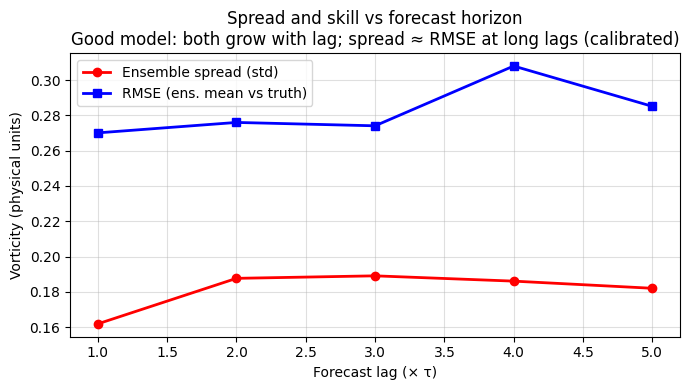

Lag  |  Ensemble spread  |  RMSE
----------------------------------------
  1τ  |  0.1619            |  0.2701
  2τ  |  0.1877            |  0.2760
  3τ  |  0.1891            |  0.2741
  4τ  |  0.1861            |  0.3079
  5τ  |  0.1820            |  0.2851


In [11]:
# ── Summarise uncertainty growth with lag ──────────────────────────────────────
#
# As lag increases, ensemble members should diverge more.
# The std across members grows → the model correctly represents growing uncertainty.

mean_spread_per_lag = []
rmse_per_lag = []

for lag in range(MAX_LAG):
    stack = np.stack(all_forecasts[lag])   # [N_MEMBERS, H, W]
    # Spread = average std across spatial locations
    mean_spread_per_lag.append(stack.std(axis=0).mean())
    # RMSE of ensemble mean vs truth (only if we have the truth)
    if lag + 1 < len(gt_frames):
        truth = to_phys(gt_frames[lag + 1])
        rmse  = np.sqrt(((stack.mean(axis=0) - truth)**2).mean())
        rmse_per_lag.append(rmse)
    else:
        rmse_per_lag.append(np.nan)

lags = np.arange(1, MAX_LAG + 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lags, mean_spread_per_lag, 'r-o', linewidth=2, label='Ensemble spread (std)')
ax.plot(lags, rmse_per_lag,        'b-s', linewidth=2, label='RMSE (ens. mean vs truth)')
ax.set_xlabel('Forecast lag (× τ)')
ax.set_ylabel('Vorticity (physical units)')
ax.set_title('Spread and skill vs forecast horizon\n'
             'Good model: both grow with lag; spread ≈ RMSE at long lags (calibrated)')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('./eval_out/spread_vs_lag.png', dpi=150)
plt.show()

print('Lag  |  Ensemble spread  |  RMSE')
print('-' * 40)
for lag, sp, rm in zip(lags, mean_spread_per_lag, rmse_per_lag):
    print(f'  {lag}τ  |  {sp:.4f}            |  {rm:.4f}')

### I think the more or less constant trend indicates that the lag between current and future time step is too large, too much chaos is already happening between the initial and the 1st step  

## Step 7 — Enstrophy spectrum: does the model reproduce the physics?

The enstrophy spectrum tells us how much vorticity lives at each spatial scale (wavenumber k).  
For 2D turbulence we expect an enstrophy cascade with a k⁻³ power law.

If our model is good, the **forecast spectrum should match the truth spectrum**.  
If it's too smooth, energy will be missing at high wavenumbers (small scales).

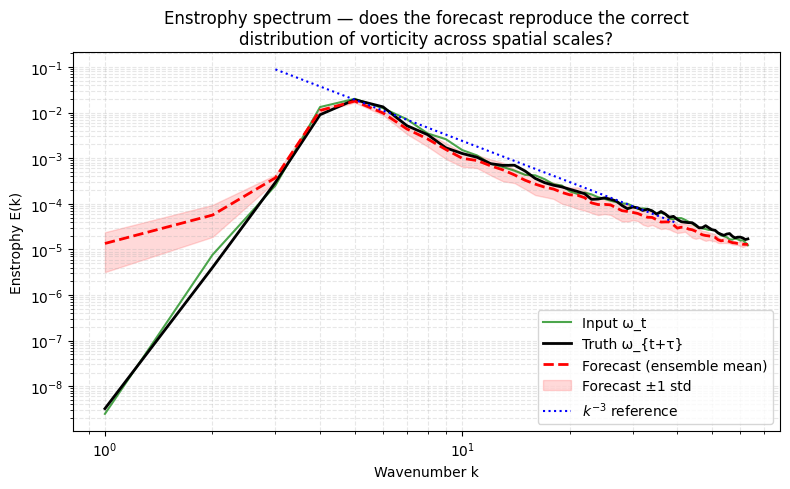

If the red dashed line overlaps the black line → the model reproduces
the correct distribution of vorticity at all spatial scales.


In [12]:
from scipy.ndimage import uniform_filter1d

def enstrophy_spectrum(omega):
    """
    Compute the enstrophy spectrum of a 2D vorticity field.

    E(k) = sum_{k <= |m| < k+1} |omega_hat(m)|^2

    omega : 2D numpy array [H, W] in physical units
    returns k_vals (wavenumbers), spectrum (enstrophy at each wavenumber)
    """
    H, W    = omega.shape
    om_hat  = np.fft.fft2(omega) / (H * W)      # normalised FFT
    om_hat  = np.fft.fftshift(om_hat)            # centre the zero frequency

    # Build a grid of wavenumber magnitudes
    ky = np.fft.fftshift(np.fft.fftfreq(H, d=1./H))
    kx = np.fft.fftshift(np.fft.fftfreq(W, d=1./W))
    KX, KY = np.meshgrid(kx, ky)
    K      = np.sqrt(KX**2 + KY**2)             # |m|

    k_max    = int(min(H, W) // 2)
    k_vals   = np.arange(0, k_max)
    spectrum = np.zeros(k_max)
    for ki in k_vals:
        mask = (K >= ki) & (K < ki + 1)
        spectrum[ki] = np.sum(np.abs(om_hat[mask])**2)

    # Light smoothing to remove saw-tooth
    spectrum = uniform_filter1d(spectrum, size=2)
    return k_vals, spectrum


# Compute spectra for: input, truth at lag 1, ensemble forecasts at lag 1
k_vals, spec_input = enstrophy_spectrum(to_phys(x0_init))
k_vals, spec_truth = enstrophy_spectrum(to_phys(gt_frames[1]) if len(gt_frames) > 1
                                        else to_phys(xhi_batch[IDX:IDX+1]))

# Average spectrum over the ensemble members at lag 1
ensemble_spectra = [enstrophy_spectrum(all_forecasts[0][e])[1] for e in range(N_MEMBERS)]
spec_ens_mean    = np.mean(ensemble_spectra, axis=0)
spec_ens_std     = np.std(ensemble_spectra,  axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

ax.loglog(k_vals[1:], spec_input[1:], 'g-',  linewidth=1.5, alpha=0.7, label='Input ω_t')
ax.loglog(k_vals[1:], spec_truth[1:], 'k-',  linewidth=2,   label='Truth ω_{t+τ}')
ax.loglog(k_vals[1:], spec_ens_mean[1:], 'r--', linewidth=2, label='Forecast (ensemble mean)')
ax.fill_between(
    k_vals[1:],
    np.clip(spec_ens_mean[1:] - spec_ens_std[1:], 1e-12, None),
    spec_ens_mean[1:] + spec_ens_std[1:],
    color='r', alpha=0.15, label='Forecast ±1 std'
)

# Reference k^{-3} line (2D turbulence enstrophy cascade)
k_ref = np.array([3, 40])
ref_level = spec_truth[5]  # anchor to truth at k=5
ax.loglog(k_ref, ref_level * (k_ref / 5.)**(-3), 'b:', linewidth=1.5, label=r'$k^{-3}$ reference')

ax.set_xlabel('Wavenumber k')
ax.set_ylabel('Enstrophy E(k)')
ax.set_title('Enstrophy spectrum — does the forecast reproduce the correct\n'
             'distribution of vorticity across spatial scales?')
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('./eval_out/enstrophy_spectrum.png', dpi=150)
plt.show()

print('If the red dashed line overlaps the black line → the model reproduces')
print('the correct distribution of vorticity at all spatial scales.')

## Short-time prediction metric
Compute the L2 distance between the correct future step and the one generated by the NN model 

In [20]:


os.makedirs('./eval_out', exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
# SHARED SPECTRAL & MOMENT UTILITIES
# ═══════════════════════════════════════════════════════════════════════════════

def radial_spectrum(field_2d):
    """Radially-averaged power spectrum of a 2D field. Returns (k_bins, power)."""
    H, W    = field_2d.shape
    fft2    = np.fft.fft2(field_2d)
    power2d = (np.abs(fft2) ** 2) / (H * W) ** 2

    kx = np.fft.fftfreq(W) * W          # integer wavenumber axes
    ky = np.fft.fftfreq(H) * H
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX ** 2 + KY ** 2)

    k_max  = int(min(H, W) // 2)
    k_bins = np.arange(1, k_max)
    power  = np.array([power2d[(K >= k - 0.5) & (K < k + 0.5)].sum()
                       for k in k_bins])
    return k_bins, power

def enstrophy_spectrum(omega):
    """Z(k) = ½ Σ |ω̂(k)|²  — direct radial power."""
    k, p = radial_spectrum(omega)
    return k, 0.5 * p

def energy_spectrum(omega):
    """E(k) = ½ Σ |ω̂(k)|²/k²  — kinetic energy from vorticity."""
    k, p = radial_spectrum(omega)
    return k, 0.5 * p / (k ** 2 + 1e-12)

def moments(field):
    """Dict of mean / var / skewness / excess-kurtosis."""
    f    = field.ravel()
    mu   = f.mean();   sigma = f.std() + 1e-12
    return dict(mean=mu, var=f.var(),
                skew=((f - mu) ** 3).mean() / sigma ** 3,
                kurt=((f - mu) ** 4).mean() / sigma ** 4 - 3)

def avg_spectra(fields, spec_fn):
    """Mean ± std of a spectrum function over a list of 2D fields."""
    specs = np.stack([spec_fn(f)[1] for f in fields])
    k     = spec_fn(fields[0])[0]
    return k, specs.mean(0), specs.std(0)

Forecasting 8/8
MAE  → mean 0.2709 ± 0.0107
RMSE → mean 0.3514 ± 0.0132


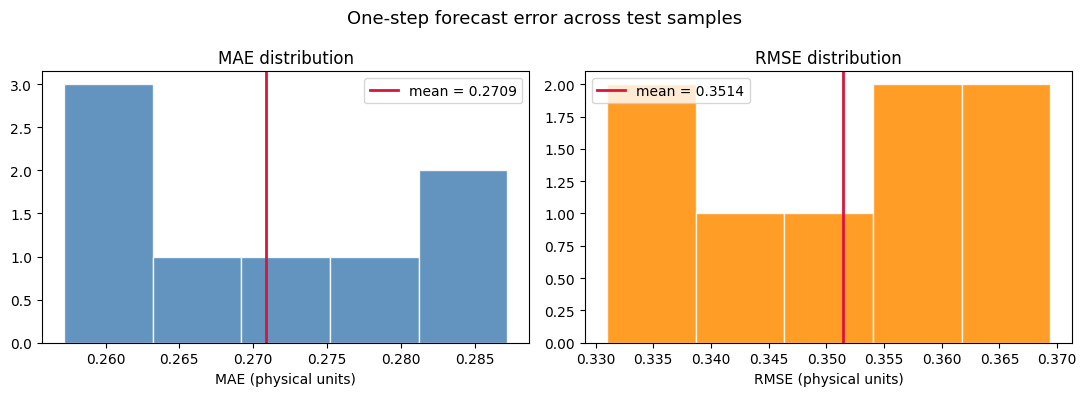

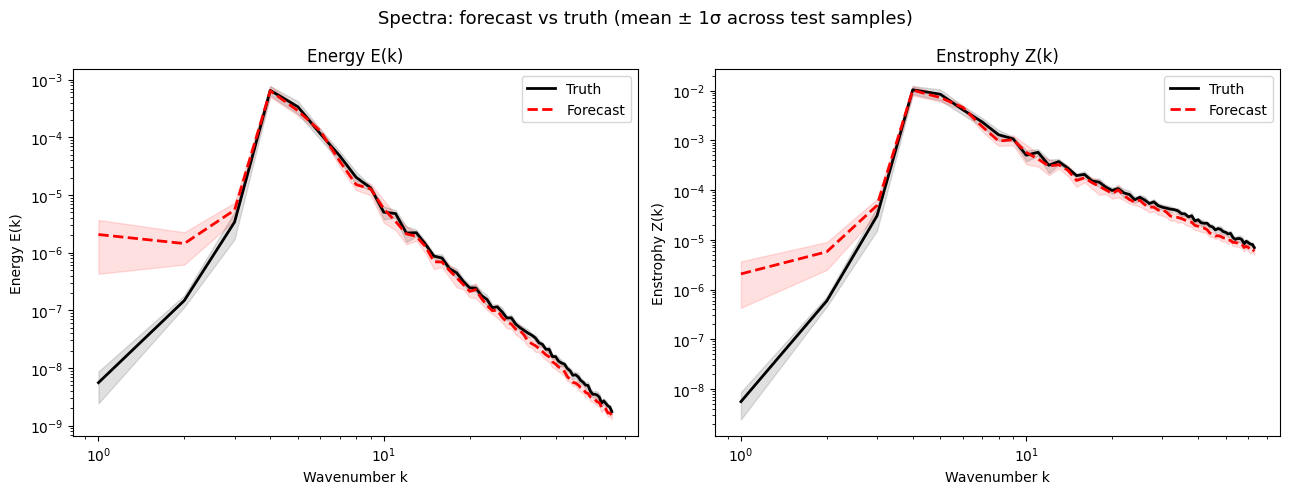

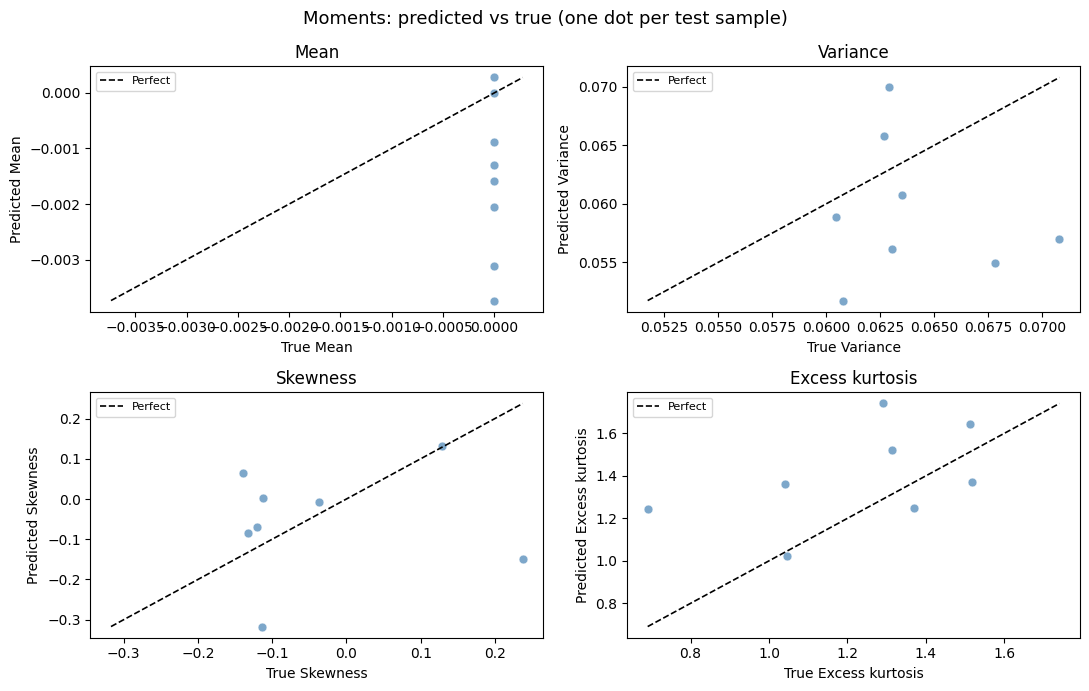

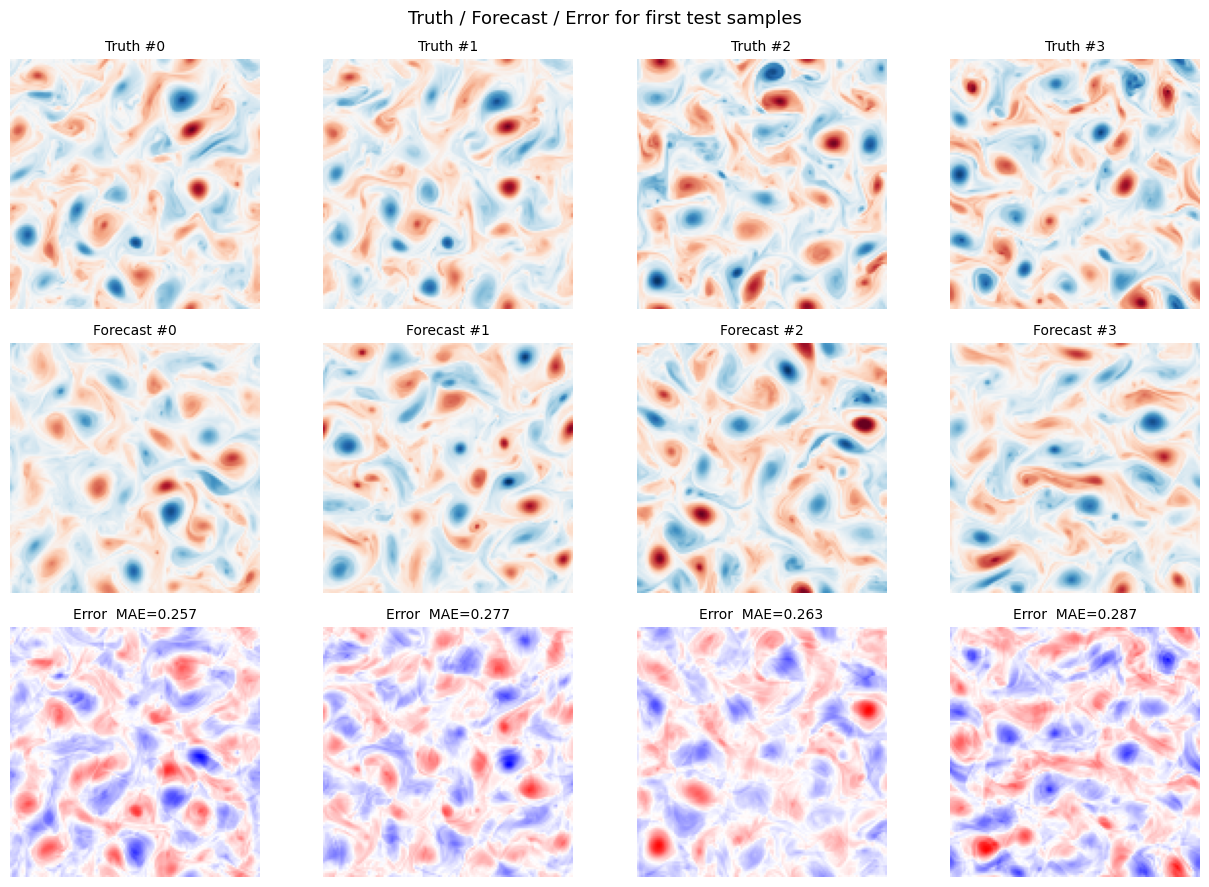

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
def tqdm(iterable, desc=""):
    total = len(iterable) if hasattr(iterable, '__len__') else '?'
    for i, item in enumerate(iterable):
        print(f"\r{desc}: {i+1}/{total}", end="", flush=True)
        yield item
    print()
import os

# ═══════════════════════════════════════════════════════════════════════════════
# SHORT-TERM: single-sample forecast vs true next state
# ═══════════════════════════════════════════════════════════════════════════════

N_SAMPLES   = xlo_batch.shape[0]
N_STEPS_SDE = 200

mae_list, rmse_list = [], []
pred_fields, true_fields = [], []

for idx in range(N_SAMPLES):
    print(f"\rForecasting {idx+1}/{N_SAMPLES}", end="", flush=True)
    x0    = xlo_batch[idx:idx+1]               # [1,1,H,W]
    x1_gt = to_phys(xhi_batch[idx:idx+1])      # [H,W] ground truth

    pred, _ = forecast_one_step(model, I, x0, n_steps=N_STEPS_SDE)
    pred_np = to_phys(pred)                    # [H,W] single prediction

    mae_list.append(np.abs(pred_np - x1_gt).mean())
    rmse_list.append(np.sqrt(((pred_np - x1_gt) ** 2).mean()))
    pred_fields.append(pred_np)
    true_fields.append(x1_gt)
print()

mae_arr  = np.array(mae_list)
rmse_arr = np.array(rmse_list)
print(f"MAE  → mean {mae_arr.mean():.4f} ± {mae_arr.std():.4f}")
print(f"RMSE → mean {rmse_arr.mean():.4f} ± {rmse_arr.std():.4f}")

# ── Error distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, arr, label, color in [
    (axes[0], mae_arr,  'MAE',  'steelblue'),
    (axes[1], rmse_arr, 'RMSE', 'darkorange'),
]:
    ax.hist(arr, bins=max(5, N_SAMPLES//3), color=color, edgecolor='white', alpha=0.85)
    ax.axvline(arr.mean(), color='crimson', lw=2, label=f'mean = {arr.mean():.4f}')
    ax.set_xlabel(f'{label} (physical units)'); ax.set_title(f'{label} distribution'); ax.legend()
plt.suptitle('One-step forecast error across test samples', fontsize=13)
plt.tight_layout()
plt.savefig('./eval_out/short_term_errors.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Spectra: predicted vs truth ───────────────────────────────────────────────
k_e, ep_mu, ep_sd = avg_spectra(pred_fields, energy_spectrum)
_,   er_mu, er_sd = avg_spectra(true_fields, energy_spectrum)
k_z, zp_mu, zp_sd = avg_spectra(pred_fields, enstrophy_spectrum)
_,   zr_mu, zr_sd = avg_spectra(true_fields, enstrophy_spectrum)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, k, pm, ps, rm, rs, ylab in [
    (axes[0], k_e, ep_mu, ep_sd, er_mu, er_sd, 'Energy E(k)'),
    (axes[1], k_z, zp_mu, zp_sd, zr_mu, zr_sd, 'Enstrophy Z(k)'),
]:
    ax.loglog(k, rm, 'k-',  lw=2, label='Truth')
    ax.fill_between(k, np.maximum(rm-rs,1e-20), rm+rs, color='black', alpha=0.12)
    ax.loglog(k, pm, 'r--', lw=2, label='Forecast')
    ax.fill_between(k, np.maximum(pm-ps,1e-20), pm+ps, color='red',   alpha=0.12)
    ax.set_xlabel('Wavenumber k'); ax.set_ylabel(ylab); ax.set_title(ylab); ax.legend()
plt.suptitle('Spectra: forecast vs truth (mean ± 1σ across test samples)', fontsize=13)
plt.tight_layout()
plt.savefig('./eval_out/short_term_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Moments: scatter predicted vs true ───────────────────────────────────────
moment_keys  = ['mean', 'var', 'skew', 'kurt']
labels_nice  = dict(mean='Mean', var='Variance', skew='Skewness', kurt='Excess kurtosis')
pred_moms    = {k: np.array([moments(f)[k] for f in pred_fields]) for k in moment_keys}
true_moms    = {k: np.array([moments(f)[k] for f in true_fields]) for k in moment_keys}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, key in zip(axes.ravel(), moment_keys):
    pm, tm = pred_moms[key], true_moms[key]
    ax.scatter(tm, pm, s=40, alpha=0.7, color='steelblue', edgecolors='white', lw=0.5)
    lo, hi = min(tm.min(), pm.min()), max(tm.max(), pm.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='Perfect')
    ax.set_xlabel(f'True {labels_nice[key]}'); ax.set_ylabel(f'Predicted {labels_nice[key]}')
    ax.set_title(labels_nice[key]); ax.legend(fontsize=8)
plt.suptitle('Moments: predicted vs true (one dot per test sample)', fontsize=13)
plt.tight_layout()
plt.savefig('./eval_out/short_term_moments.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Visual comparison: a few samples side by side ────────────────────────────
N_VIZ = min(4, N_SAMPLES)
fig, axes = plt.subplots(3, N_VIZ, figsize=(3.2*N_VIZ, 9))
for i in range(N_VIZ):
    vmax = np.abs(true_fields[i]).max()
    norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
    err  = pred_fields[i] - true_fields[i]

    axes[0,i].imshow(true_fields[i],  cmap='RdBu_r', norm=norm)
    axes[0,i].set_title(f'Truth #{i}',     fontsize=10); axes[0,i].axis('off')
    axes[1,i].imshow(pred_fields[i],  cmap='RdBu_r', norm=norm)
    axes[1,i].set_title(f'Forecast #{i}',  fontsize=10); axes[1,i].axis('off')
    axes[2,i].imshow(err, cmap='bwr',
                     vmin=-np.abs(err).max(), vmax=np.abs(err).max())
    axes[2,i].set_title(f'Error  MAE={mae_arr[i]:.3f}', fontsize=10); axes[2,i].axis('off')

axes[0,0].set_ylabel('Truth',    fontsize=11)
axes[1,0].set_ylabel('Forecast', fontsize=11)
axes[2,0].set_ylabel('Error',    fontsize=11)
plt.suptitle('Truth / Forecast / Error for first test samples', fontsize=13)
plt.tight_layout()
plt.savefig('./eval_out/short_term_visual.png', dpi=150, bbox_inches='tight')
plt.show()

Short-term experiment: 8 initial conditions, ensemble size 4, 200 SDE steps
Short-term: 8/8


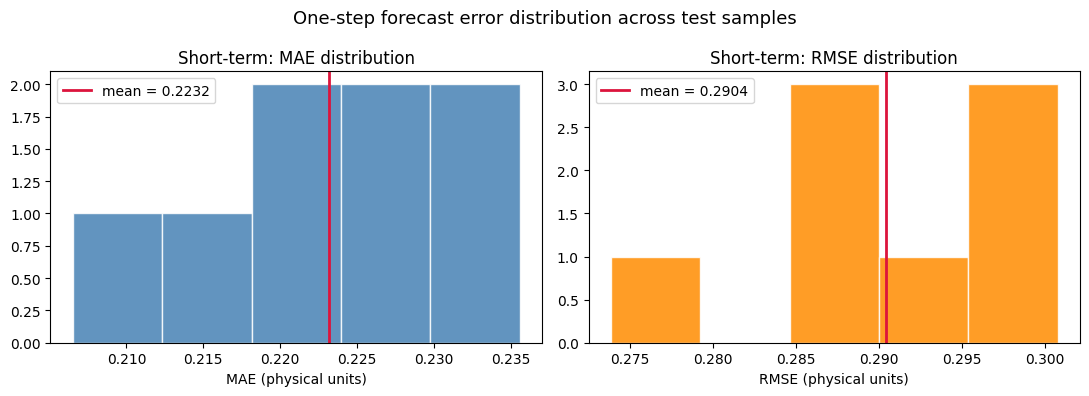

  MAE  → mean 0.2232 ± 0.0080
  RMSE → mean 0.2904 ± 0.0081


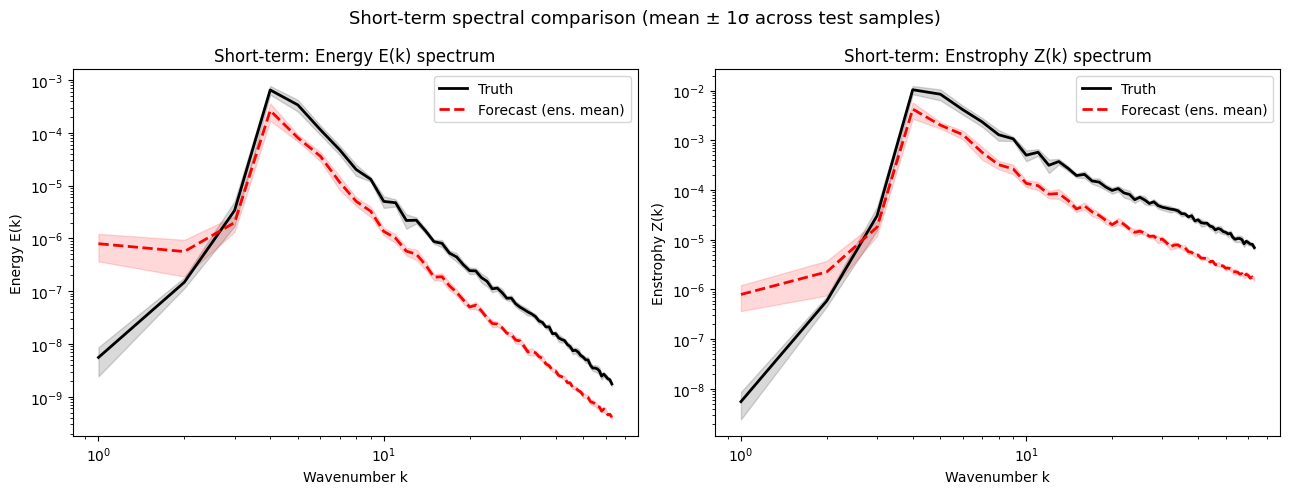

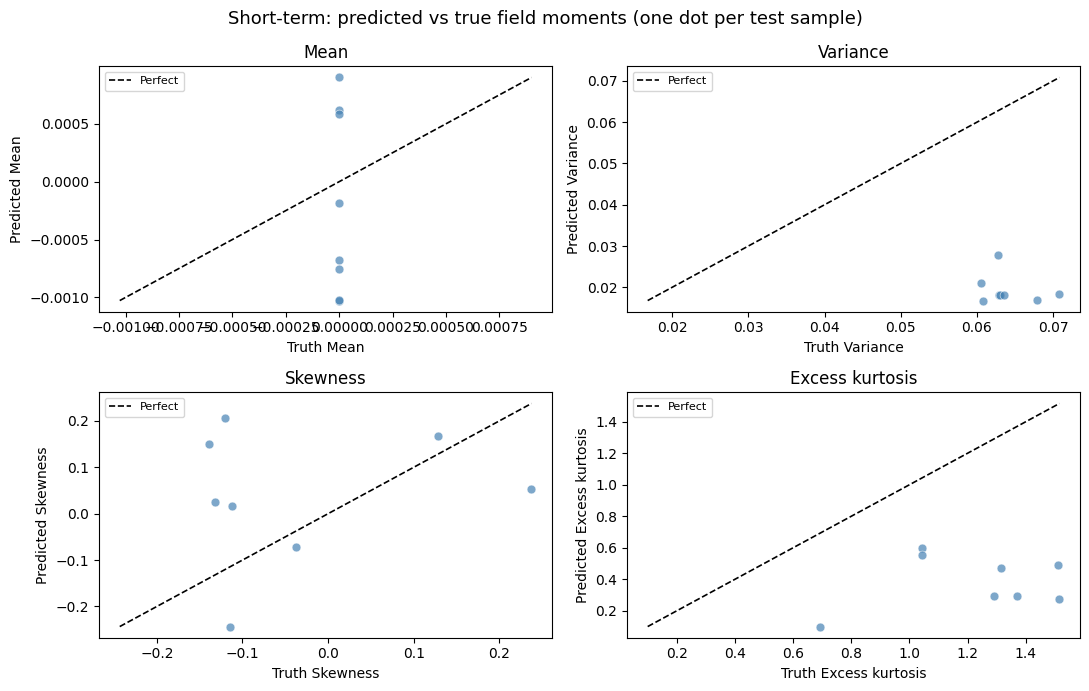


Long-term experiment: 8 rollouts × 5 steps
Long-term rollout: 8/8


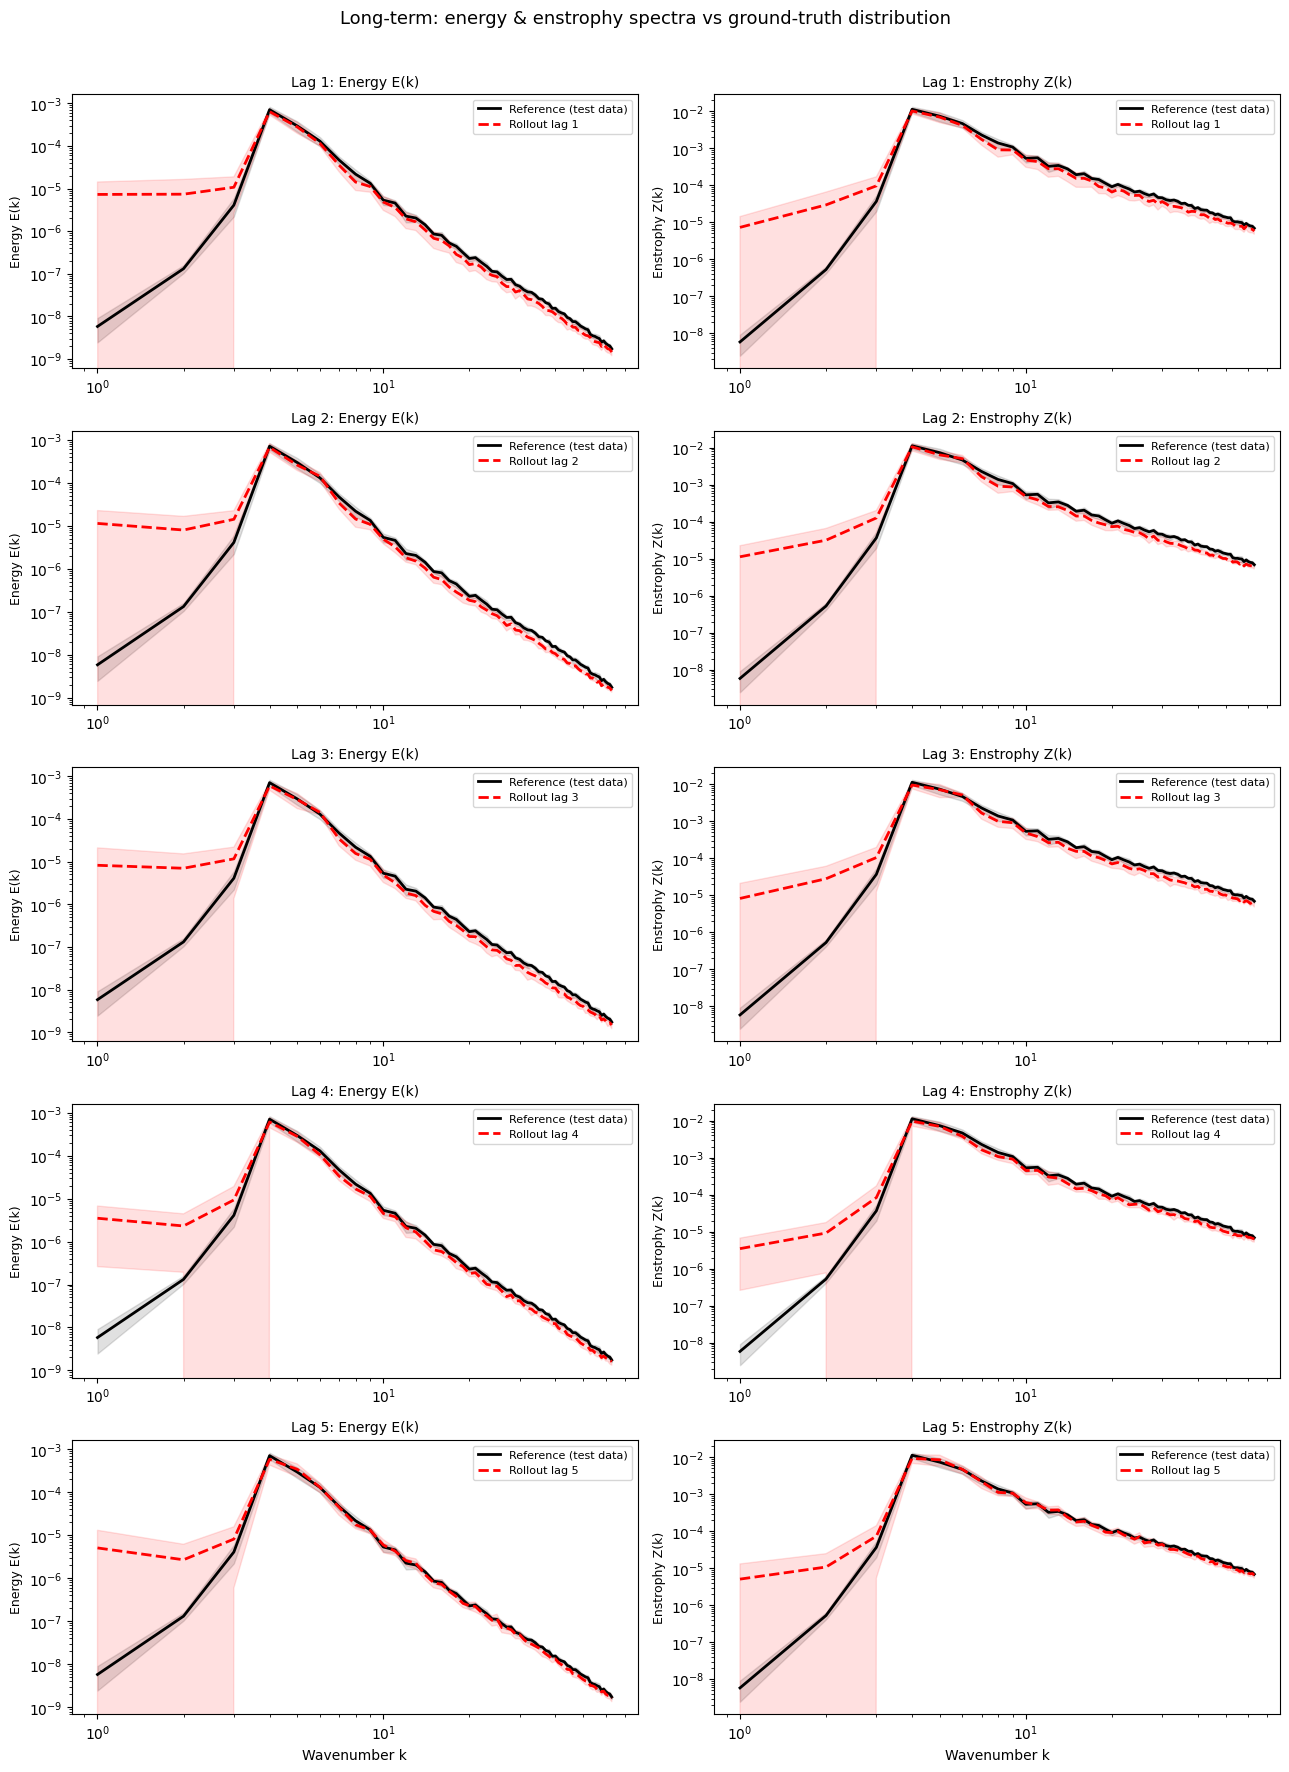

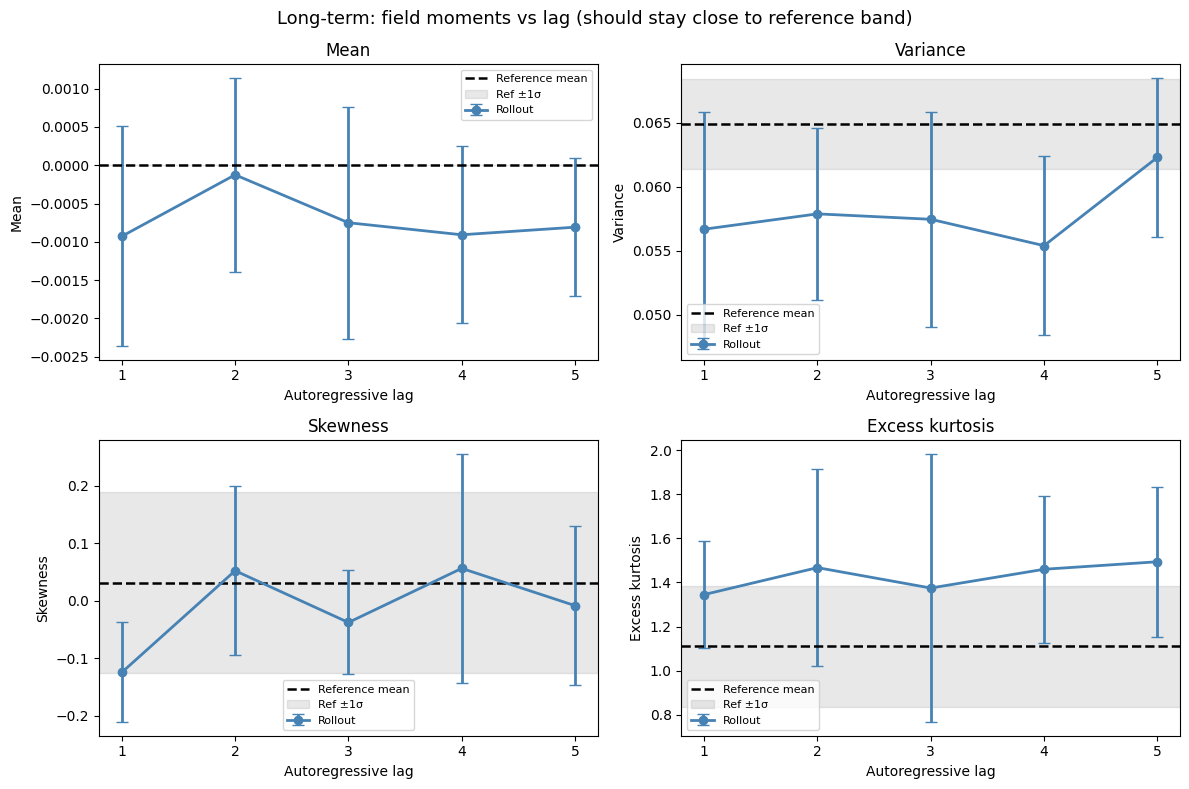

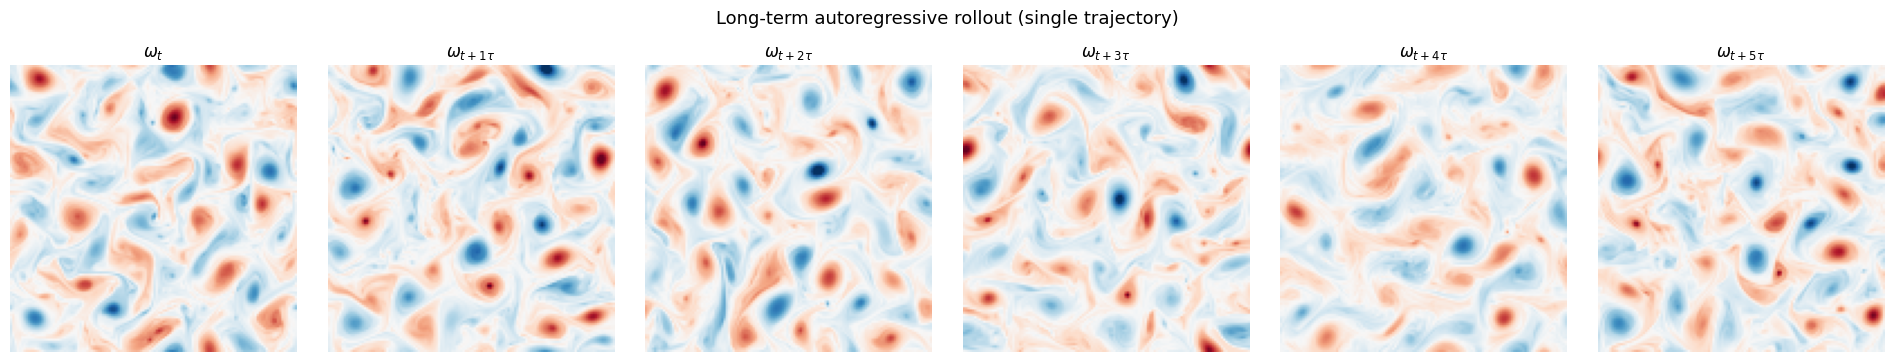


══════════════════════════════════════════════════════════════
 Lag |       Mean        Var       Skew       Kurt
──────────────────────────────────────────────────────────────
 REF |     0.0000     0.0649     0.0318     1.1104
──────────────────────────────────────────────────────────────
   1 |    -0.0009     0.0567    -0.1243     1.3452
   2 |    -0.0001     0.0579     0.0524     1.4674
   3 |    -0.0008     0.0575    -0.0375     1.3749
   4 |    -0.0009     0.0554     0.0565     1.4600
   5 |    -0.0008     0.0623    -0.0082     1.4941
══════════════════════════════════════════════════════════════


In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# ❷  LONG-TERM EXPERIMENT  (5-step autoregressive rollout)
# ═══════════════════════════════════════════════════════════════════════════════

def rollout(model, interpolant, x0_phys_np, n_lag=5, n_steps=200, pixel_norm=1.0):
    """
    Autoregressively apply forecast_one_step for n_lag steps.
    x0_phys_np : [H, W] numpy array in physical units.
    Returns list of [H, W] numpy arrays (one per lag, not including x0).
    """
    # normalise back to model input space
    x = torch.tensor(x0_phys_np / pixel_norm,
                     dtype=torch.float32, device=next(model.parameters()).device)
    x = x.unsqueeze(0).unsqueeze(0)    # [1, 1, H, W]
    trajectory = []
    for _ in range(n_lag):
        x, _ = forecast_one_step(model, interpolant, x, n_steps=n_steps)
        trajectory.append(x[0, 0].cpu().numpy() * pixel_norm)
    return trajectory

N_ROLLOUTS  = min(N_SAMPLES, 8)    # how many independent rollout seeds
N_LAG       = 5                    # number of autoregressive steps
N_STEPS_LT  = 200

print(f"\nLong-term experiment: {N_ROLLOUTS} rollouts × {N_LAG} steps")

# Ground-truth fields at each lag (using the test batch as reference distribution)
# We treat ALL fields in xhi_batch as draws from the target distribution at lag 1
# and all fields in xlo_batch as the lag-0 distribution.
gt_fields_lag0 = [to_phys(xlo_batch[i:i+1]) for i in range(N_SAMPLES)]

# ── Run rollouts ──────────────────────────────────────────────────────────────
rollout_by_lag = {lag: [] for lag in range(1, N_LAG + 1)}   # lag → list of [H,W]

for idx in tqdm(range(N_ROLLOUTS), desc="Long-term rollout"):
    x0_np    = to_phys(xlo_batch[idx:idx+1])
    traj     = rollout(model, I, x0_np, n_lag=N_LAG,
                       n_steps=N_STEPS_LT, pixel_norm=old_pixel_norm)
    for lag, field in enumerate(traj, start=1):
        rollout_by_lag[lag].append(field)

# ── Plot 2a: spectral comparison across lags ──────────────────────────────────
fig, axes = plt.subplots(N_LAG, 2, figsize=(13, 3.5 * N_LAG))
fig.suptitle('Long-term: energy & enstrophy spectra vs ground-truth distribution',
             fontsize=13, y=1.01)

for lag in range(1, N_LAG + 1):
    pred_lag = rollout_by_lag[lag]

    # Use the observed (lag-0) fields as reference distribution for long lags;
    # you can substitute ground-truth lag-τ data here if available.
    ref_fields = gt_fields_lag0

    k_e, ep_mu, ep_sd = avg_spectra(pred_lag,  energy_spectrum)
    _,   er_mu, er_sd = avg_spectra(ref_fields, energy_spectrum)
    k_z, zp_mu, zp_sd = avg_spectra(pred_lag,  enstrophy_spectrum)
    _,   zr_mu, zr_sd = avg_spectra(ref_fields, enstrophy_spectrum)

    for ax, k, pm, ps, rm, rs, ylab in [
        (axes[lag-1, 0], k_e, ep_mu, ep_sd, er_mu, er_sd, 'Energy E(k)'),
        (axes[lag-1, 1], k_z, zp_mu, zp_sd, zr_mu, zr_sd, 'Enstrophy Z(k)'),
    ]:
        ax.loglog(k, rm, 'k-',  lw=2, label='Reference (test data)')
        ax.fill_between(k, rm - rs, rm + rs, color='black', alpha=0.12)
        ax.loglog(k, pm, 'r--', lw=2, label=f'Rollout lag {lag}')
        ax.fill_between(k, pm - ps, pm + ps, color='red',   alpha=0.12)
        ax.set_ylabel(ylab, fontsize=9);  ax.legend(fontsize=8)
        ax.set_title(f'Lag {lag}: {ylab}', fontsize=10)
        if lag == N_LAG:
            ax.set_xlabel('Wavenumber k')

plt.tight_layout()
plt.savefig('./eval_out/long_term_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2b: moments vs lag ───────────────────────────────────────────────────
ref_moms_arr = {k: np.array([moments(f)[k] for f in gt_fields_lag0])
                for k in moment_keys}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, key in zip(axes.ravel(), moment_keys):
    # Rollout moments at each lag
    lags_arr   = list(range(1, N_LAG + 1))
    pred_means = [np.mean([moments(f)[key] for f in rollout_by_lag[l]]) for l in lags_arr]
    pred_stds  = [np.std( [moments(f)[key] for f in rollout_by_lag[l]]) for l in lags_arr]

    ref_mu = ref_moms_arr[key].mean()
    ref_sd = ref_moms_arr[key].std()

    ax.errorbar(lags_arr, pred_means, yerr=pred_stds,
                fmt='o-', color='steelblue', capsize=4, lw=2, label='Rollout')
    ax.axhline(ref_mu,  color='black', lw=1.8, ls='--', label='Reference mean')
    ax.axhspan(ref_mu - ref_sd, ref_mu + ref_sd,
               color='grey', alpha=0.18, label='Ref ±1σ')
    ax.set_xlabel('Autoregressive lag');  ax.set_ylabel(labels_nice[key])
    ax.set_title(labels_nice[key]);  ax.legend(fontsize=8)
    ax.set_xticks(lags_arr)

plt.suptitle('Long-term: field moments vs lag (should stay close to reference band)',
             fontsize=13)
plt.tight_layout()
plt.savefig('./eval_out/long_term_moments_vs_lag.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2c: visual snapshots of the rollout ──────────────────────────────────
IDX_VIZ  = 0
x0_np    = to_phys(xlo_batch[IDX_VIZ:IDX_VIZ+1])
traj_viz = [x0_np] + rollout(model, I, x0_np, n_lag=N_LAG,
                              n_steps=N_STEPS_LT, pixel_norm=old_pixel_norm)

vmax_viz = np.abs(x0_np).max()
norm_viz = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax_viz, vmax=vmax_viz)

fig, axes = plt.subplots(1, N_LAG + 1, figsize=(3.2 * (N_LAG + 1), 3.5))
for i, (ax, field) in enumerate(zip(axes, traj_viz)):
    ax.imshow(field, cmap='RdBu_r', norm=norm_viz)
    ax.set_title(r'$\omega_t$' if i == 0 else fr'$\omega_{{t+{i}\tau}}$', fontsize=12)
    ax.axis('off')
plt.suptitle('Long-term autoregressive rollout (single trajectory)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('./eval_out/long_term_rollout_viz.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "═"*62)
print(f"{'Lag':>4} | {'Mean':>10} {'Var':>10} {'Skew':>10} {'Kurt':>10}")
print("─"*62)
ref_row = {k: ref_moms_arr[k].mean() for k in moment_keys}
print(f"{'REF':>4} | {ref_row['mean']:>10.4f} {ref_row['var']:>10.4f} "
      f"{ref_row['skew']:>10.4f} {ref_row['kurt']:>10.4f}")
print("─"*62)
for lag in range(1, N_LAG + 1):
    m = {k: np.mean([moments(f)[k] for f in rollout_by_lag[lag]]) for k in moment_keys}
    print(f"{lag:>4} | {m['mean']:>10.4f} {m['var']:>10.4f} "
          f"{m['skew']:>10.4f} {m['kurt']:>10.4f}")
print("═"*62)